In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
before_cal = np.loadtxt(r"C:\Users\BaughLaflamme\Desktop\Qblox Master Folder\QBlox Tutorials\QCM-RF\mixer calibration data\Nov 12 -13 2024\before cal c3 2.txt")
#plt.plot(before_cal[0:2500])

In [3]:
after_cal = np.loadtxt(r"C:\Users\BaughLaflamme\Desktop\Qblox Master Folder\QBlox Tutorials\QCM-RF\mixer calibration data\Nov 12 -13 2024\after cal c3.txt")
#plt.plot(after_cal[3700:4500])

In [4]:
def rms(data):
	s = 0
	for i in data:
		s += i**2
	ms = s/len(data)
	rms = np.sqrt(ms)
	return rms

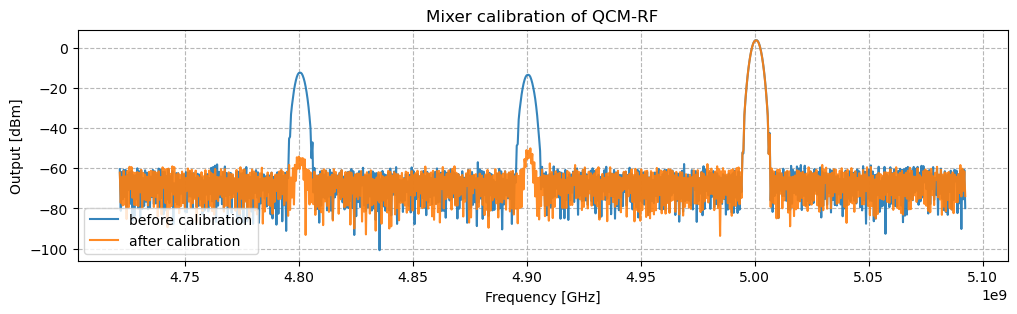

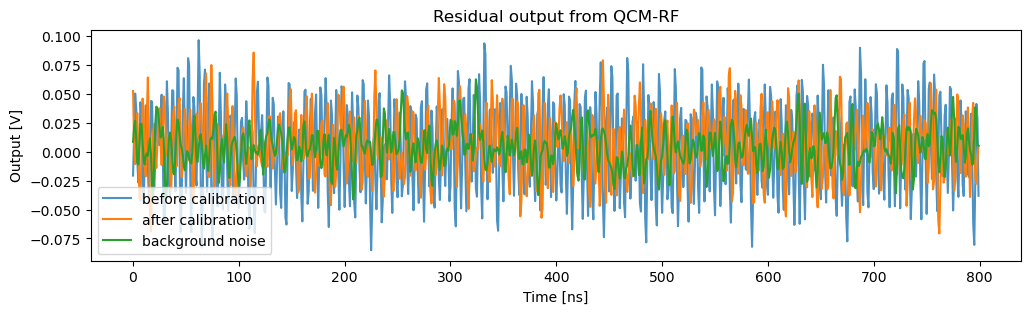

Output RMS before calibration: 0.0385
Output RMS after calibration: 0.0271
Noise RMS before calibration: 0.0171
Noise RMS after calibration: 0.0169
The calibrated RMS is 29.8% better than the uncalibrated RMS, and is 60.6% greater than the noise


In [9]:
low = 50
high = 920

spectrum_before = np.loadtxt(r"C:\Users\BaughLaflamme\Desktop\Qblox Master Folder\QBlox Tutorials\QCM-RF\mixer calibration data\Nov 12 -13 2024\no cal.csv", delimiter=",")
freqs_b = spectrum_before[:,0][low:high]
dbm_b = spectrum_before[:,1][low:high]
spectrum_after = np.loadtxt(r"C:\Users\BaughLaflamme\Desktop\Qblox Master Folder\QBlox Tutorials\QCM-RF\mixer calibration data\Nov 12 -13 2024\after cal.csv", delimiter=",")
freqs_a = spectrum_after[:,0][low:high]
dbm_a = spectrum_after[:,1][low:high]

fig, ax = plt.subplots(1, 1, figsize = (12, 3))
ax.grid(ls="--", alpha = 0.9)
ax.plot(freqs_b, dbm_b, alpha = 0.9, label = "before calibration")
ax.plot(freqs_a, dbm_a, alpha = 0.9, label = "after calibration")
ax.set_title("Mixer calibration of QCM-RF")
ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel("Output [dBm]")
plt.legend(loc = "lower left")
plt.show()


fig, ax = plt.subplots(1, 1, figsize = (12, 3))
ax.plot(before_cal[3700:4500], alpha = 0.8, label = "before calibration")
ax.plot(after_cal[3700:4500], alpha = 1, label = "after calibration")
ax.plot(after_cal[:800], alpha = 1, label = "background noise")
ax.set_title("Residual output from QCM-RF")
ax.set_xlabel("Time [ns]")
ax.set_ylabel("Output [V]")
plt.legend(loc = "lower left")
plt.show()

# Calculate the RMS of each
data_before = before_cal[3700:4500]
data_after = after_cal[3700:4500]
data_noise_before = before_cal[0:2500]
data_noise_after = after_cal[0:2500]

rms_before = rms(data_before)
rms_after = rms(data_after)
rms_noise_before = rms(data_noise_before)
rms_noise_after = rms(data_noise_after)
print("Output RMS before calibration: {:.3}\nOutput RMS after calibration: {:.3}".format(rms_before, rms_after))
print("Noise RMS before calibration: {:.3}\nNoise RMS after calibration: {:.3}".format(rms_noise_before, rms_noise_after))

cal_ratio_decrease = 100 - ((rms_after/rms_before)*100)
noise_ratio = ((rms_after/rms_noise_after)*100) - 100

print("The calibrated RMS is {:.3}% better than the uncalibrated RMS, and is {:.3}% greater than the noise".format(cal_ratio_decrease, noise_ratio))